# 01 — Quels facteurs pèsent le plus pour gagner un match ?

**Problématique.** Identifier, statistiquement, les facteurs de jeu qui font gagner
un match de LFB, et chiffrer leur effet (« +1 d'avantage sur X → +Y % de victoire »).

**Donnée.** `data/equipes_fusionnees.csv` : une ligne par joueuse et par match.

**Méthode.**
1. Agréger les stats des joueuses au niveau **équipe × match**.
2. Passer en **différentiel équipe − adversaire** : une stat ne fait gagner que
   comparée à celle d'en face (tirer à 45 % ne sert que si l'adverse fait moins bien).
3. Mesurer l'importance par **trois lectures complémentaires** pour ne pas se faire
   piéger par la corrélation entre stats : univariée, multivariée (variables non
   redondantes), et Random Forest.

In [1]:
import sys
from pathlib import Path
p = Path.cwd()
while not (p / "analyse" / "outils.py").exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p / "analyse"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import outils as o
OUT = o.RESULTATS / "facteurs"; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)
print("outils charges, sorties ->", OUT)

outils charges, sorties -> C:\Users\TEMP.IUT-LUMIERE.000\R6.06-Domaines-d-application-de-la-statistique\analyse\resultats\facteurs


## 1. Chargement, agrégation et indicateurs

On agrège par équipe×match (somme des joueuses), puis on construit des indicateurs
avancés : **eFG%** (efficacité au tir valorisant le 3pts), **taux de pertes**
(ballons perdus / possession), **% à 3pts**, **pression défensive** (interceptions +
contres). La possession suit la formule standard
`tirs_tentés − rebonds_off + ballons_perdus + 0.44 × lancers_tentés`.

In [2]:
df = o.charger_equipes(o.SAISONS_COMPLETES)
t = o.agreger_equipe_match(df)

eps = 1e-9
t["poss"]         = t["Tirs_tentes"] - t["RO"] + t["BP"] + 0.44 * t["LF_tentes"]
t["eFG"]          = (t["Tirs_marques"] + 0.5 * t["3pts_marques"]) / (t["Tirs_tentes"] + eps)
t["pct_tirs"]     = t["Tirs_marques"] / (t["Tirs_tentes"] + eps)
t["pct_3pts"]     = t["3pts_marques"] / (t["3pts_tentes"] + eps)
t["part_3pts"]    = t["3pts_tentes"] / (t["Tirs_tentes"] + eps)
t["taux_pertes"]  = t["BP"] / (t["poss"] + eps)
t["pression_def"] = t["INT"] + t["CT"]

stats = ["eFG", "pct_tirs", "pct_3pts", "part_3pts", "taux_pertes",
         "RO", "RD", "PD", "INT", "CT", "pression_def"]
m = o.differentiel_adversaire(t, stats)
print(f"{len(t)} equipe-matchs, {len(m)} confrontations appariees")
print(m.filter(like="d_").head(3).round(3).to_string())

438 equipe-matchs, 358 confrontations appariees
   d_eFG  d_pct_tirs  d_pct_3pts  d_part_3pts  d_taux_pertes  d_RO  d_RD  d_PD  d_INT  d_CT  d_pression_def
2  0.146       0.107       0.247        0.010         -0.192   3.0  -2.0   5.0    9.0   0.0             9.0
3 -0.146      -0.107      -0.247       -0.010          0.192  -3.0   2.0  -5.0   -9.0   0.0            -9.0
8 -0.095      -0.110       0.036        0.087          0.072   1.0  -3.0   6.0   -6.0   1.0            -5.0


## 2. Importance univariée

Chaque facteur **seul** : effet en points de probabilité de victoire pour **+1
écart-type d'avantage** sur l'adversaire (depuis un match équilibré à 50 %), et son
AUC isolé (0.5 = hasard, 1 = parfait). Lecture insensible à la colinéarité entre stats.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

LABELS = {"d_eFG":"Efficacite tir (eFG%)","d_pct_tirs":"% tirs reussis",
          "d_pct_3pts":"% a 3 points","d_part_3pts":"Part de tirs 3pts (style)",
          "d_taux_pertes":"Taux de pertes","d_RO":"Rebonds offensifs",
          "d_RD":"Rebonds defensifs","d_PD":"Passes decisives",
          "d_INT":"Interceptions","d_CT":"Contres","d_pression_def":"Pression def. (INT+CT)"}

y = m["Victoire"].values
lignes = []
for c in [f"d_{s}" for s in stats]:
    d = m.dropna(subset=[c]); x = StandardScaler().fit_transform(d[[c]].values)
    clf = LogisticRegression(max_iter=2000).fit(x, d["Victoire"].values)
    coef = clf.coef_[0][0]
    lignes.append({"facteur": LABELS[c], "effet_proba_%": coef*0.25*100,
                   "auc_seul": roc_auc_score(d["Victoire"], clf.predict_proba(x)[:,1]),
                   "importance": abs(coef)})
uni = pd.DataFrame(lignes).sort_values("importance", ascending=False).reset_index(drop=True)
uni.to_csv(OUT / "importance_univariee.csv", index=False)
print(uni.round(2).to_string(index=False))

                  facteur  effet_proba_%  auc_seul  importance
           % tirs reussis          63.46      0.91        2.54
    Efficacite tir (eFG%)          62.82      0.92        2.51
         Passes decisives          41.79      0.85        1.67
             % a 3 points          33.45      0.79        1.34
        Rebonds defensifs          31.67      0.78        1.27
           Taux de pertes         -18.25      0.68        0.73
   Pression def. (INT+CT)          17.01      0.68        0.68
            Interceptions          15.53      0.67        0.62
                  Contres           4.51      0.55        0.18
        Rebonds offensifs           3.99      0.56        0.16
Part de tirs 3pts (style)          -1.94      0.50        0.08


**Lecture.** L'**efficacité au tir** domine, suivie des **passes décisives** et du
**% à 3 points** : un championnat tranché par l'adresse et le jeu collectif. La part de
tirs à 3pts (un *choix* de style, pas une réussite) a un effet faible → style ≠ facteur
de victoire.

## 3. Modèle multivarié (variables non redondantes)

On combine un seul représentant par concept (sinon les variables corrélées se volent
leurs coefficients et les signes deviennent absurdes). Les signes doivent être cohérents
et le modèle prédictif.

In [4]:
from sklearn.model_selection import cross_val_score
feats = ["d_eFG","d_pct_3pts","d_taux_pertes","d_RD","d_RO","d_PD","d_pression_def"]
d = m.dropna(subset=feats+["Victoire"])
X = StandardScaler().fit_transform(d[feats].values); y = d["Victoire"].values
clf = LogisticRegression(max_iter=2000).fit(X, y)
auc = cross_val_score(clf, X, y, cv=5, scoring="roc_auc").mean()
acc = cross_val_score(clf, X, y, cv=5, scoring="accuracy").mean()
multi = (pd.DataFrame({"facteur":[LABELS[f] for f in feats], "coef_std":clf.coef_[0],
                       "odds_ratio":np.exp(clf.coef_[0]), "effet_proba_%":clf.coef_[0]*0.25*100})
         .sort_values("coef_std", key=abs, ascending=False).reset_index(drop=True))
multi.to_csv(OUT / "modele_multivarie.csv", index=False)
print(f"AUC={auc:.3f}  accuracy={acc:.3f}  (validation croisee 5-fold)\n")
print(multi.round(3).to_string(index=False))

AUC=0.990  accuracy=0.936  (validation croisee 5-fold)

               facteur  coef_std  odds_ratio  effet_proba_%
 Efficacite tir (eFG%)     4.157      63.865        103.919
        Taux de pertes    -2.877       0.056        -71.925
     Rebonds defensifs     1.318       3.734         32.938
     Rebonds offensifs     1.249       3.486         31.220
          % a 3 points     0.408       1.503         10.190
Pression def. (INT+CT)     0.178       1.195          4.449
      Passes decisives    -0.089       0.914         -2.237


## 4. Random Forest — contre-vérification non linéaire

Si un gros effet non linéaire nous échappait, la forêt le révélerait. Elle sert ici de
garde-fou et fournit un classement d'importance indépendant.

In [5]:
from sklearn.ensemble import RandomForestClassifier
feats_rf = [f"d_{s}" for s in stats]
d = m.dropna(subset=feats_rf+["Victoire"])
rf = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=5, random_state=0)
rf.fit(d[feats_rf].values, d["Victoire"].values)
auc_rf = cross_val_score(rf, d[feats_rf].values, d["Victoire"].values, cv=5, scoring="roc_auc").mean()
imp = (pd.DataFrame({"facteur":[LABELS[f] for f in feats_rf], "importance_rf":rf.feature_importances_})
       .sort_values("importance_rf", ascending=False).reset_index(drop=True))
imp.to_csv(OUT / "importance_rf.csv", index=False)
print(f"AUC Random Forest = {auc_rf:.3f}\n")
print(imp.round(3).to_string(index=False))

AUC Random Forest = 0.966

                  facteur  importance_rf
    Efficacite tir (eFG%)          0.322
           % tirs reussis          0.211
         Passes decisives          0.130
           Taux de pertes          0.088
        Rebonds defensifs          0.072
             % a 3 points          0.065
        Rebonds offensifs          0.035
   Pression def. (INT+CT)          0.028
            Interceptions          0.028
Part de tirs 3pts (style)          0.012
                  Contres          0.008


## 5. Graphique de synthèse

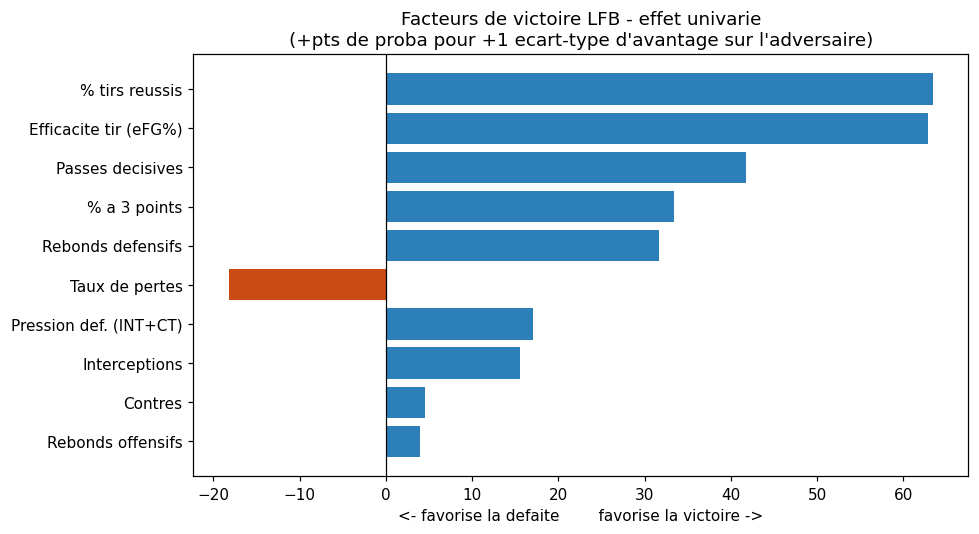

In [6]:
top = uni.head(10).iloc[::-1]
plt.figure(figsize=(9,5))
col = ["#2c7fb8" if v>0 else "#cb4b16" for v in top["effet_proba_%"]]
plt.barh(top["facteur"], top["effet_proba_%"], color=col)
plt.axvline(0, color="black", lw=.8)
plt.title("Facteurs de victoire LFB - effet univarie\n(+pts de proba pour +1 ecart-type d'avantage sur l'adversaire)")
plt.xlabel("<- favorise la defaite        favorise la victoire ->")
plt.tight_layout(); plt.savefig(OUT / "facteurs_victoire.png", dpi=130); plt.show()

## Conclusion

- **Gagner = être efficace, pas jouer vite.** La possession en soi ne compte pas (les
  deux équipes en ont autant) ; ce qui compte est ce qu'on en fait : marquer (eFG, 3pts),
  ne pas gâcher (pertes), récupérer (rebond défensif).
- **Le 3-points est un grand discriminant** (souvent en tête du Random Forest).
- **Le collectif > l'individuel** : les passes décisives pèsent fort.
- **Limite** : corrélation ≠ causalité. Ces facteurs *accompagnent* la victoire ; les
  forcer ne la garantit pas. Le notebook 05 montre d'ailleurs que pour **prédire** un
  match (avant qu'il soit joué), seul le niveau (ELO) compte — pas ces facteurs mesurés
  pendant le match.

Résultats exportés dans `resultats/facteurs/`.